# Error Analysis — 2-Model × 2-Condition Dose Prediction

This notebook investigates *where* and *why* the models fail, based on Arun's advice (2026-06-03):  
understand errors before adding ablations. Analyses use the 20 per-fold validation CSVs (all 4 conditions × 5 folds, ~367 patients each) and the preprocessed pickles for anatomy features.

**Sections:**
1. Load all evaluation CSVs into one tidy DataFrame  
2. Error distribution — histograms and percentiles  
3. Cross-model consistency — are the same patients hard for both models?  
4. oldAcq vs newAcq — acquisition group deep-dive  
5. Structure-level error breakdown  
6. Signed bias — systematic over/under-prediction  
7. Worst-patient characterisation  
8. Anatomy features from pickles — structure volumes vs error  
9. Geom channels — patient-level delta (who benefits, who regresses)  
10. Per-fold variance  

In [ ]:
import sys, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sys.path.insert(0, '/gpfs/scratch1/shared/akhalil/data/thesis-doseprediction')

# Reproducible figures
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = {'unet_base': '#2196F3', 'dgan_base': '#FF5722',
          'unet_geom': '#64B5F6', 'dgan_geom': '#FF8A65'}
LABELS = {'unet_base': 'U-Net baseline', 'dgan_base': 'DoseGAN baseline',
          'unet_geom': 'U-Net geom',     'dgan_geom': 'DoseGAN geom'}

## 1. Load evaluation CSVs

In [2]:
EVAL_DIR = '/gpfs/scratch1/shared/akhalil/data/thesis-doseprediction/outputs/evaluation/'
PICKLE_DIR = '/gpfs/scratch1/shared/akhalil/data/thesis-doseprediction/data/pickles/'

def load_condition(pattern, condition_label):
    dfs = []
    for p in sorted(glob.glob(pattern)):
        df = pd.read_csv(p)
        fold_num = int(p.split('fold')[1].split('_')[0])
        df['_fold'] = fold_num
        df['condition'] = condition_label
        # drop the 'model' column from geom CSVs (already encoded in condition)
        if 'model' in df.columns:
            df = df.drop(columns=['model'])
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

unet_base = load_condition(EVAL_DIR + 'unet3d_*.csv',  'unet_base')
dgan_base = load_condition(EVAL_DIR + 'dosegan_*.csv', 'dgan_base')
unet_geom = load_condition(EVAL_DIR + 'unet3d_ch32_sigmoid_geom*.csv', 'unet_geom')
dgan_geom = load_condition(EVAL_DIR + 'dosegan_ngf32_sigmoid_geom*.csv','dgan_geom')

all_df = pd.concat([unet_base, dgan_base, unet_geom, dgan_geom], ignore_index=True)

print('Patients per condition:')
print(all_df.groupby('condition')['patient_id'].count())
print(f'\nUnique patients: {all_df["patient_id"].nunique()}')
print(f'Conditions: {all_df["condition"].unique().tolist()}')

Patients per condition:
condition
dgan_base    367
dgan_geom    368
unet_base    367
unet_geom    367
Name: patient_id, dtype: int64

Unique patients: 368
Conditions: ['unet_base', 'dgan_base', 'unet_geom', 'dgan_geom']


In [3]:
# Summary table: fold-mean ± fold-std for key metrics
def fold_summary(df, col):
    m = df.groupby('_fold')[col].mean()
    return f'{m.mean():.3f} ± {m.std():.3f}'

metrics = ['body_MAE_Gy', 'body_RMSE_Gy', 'ptv_MAE_Gy', 'rectum_MAE_Gy', 'bladder_MAE_Gy',
           'boundary_MAE_ptv_Gy', 'boundary_MAE_rectum_Gy', 'boundary_MAE_bladder_Gy']

rows = []
for cond, df in [('unet_base', unet_base), ('dgan_base', dgan_base),
                 ('unet_geom', unet_geom), ('dgan_geom', dgan_geom)]:
    row = {'condition': cond}
    for m in metrics:
        row[m] = fold_summary(df, m)
    rows.append(row)

pd.set_option('display.max_colwidth', 20)
pd.DataFrame(rows).set_index('condition')

,body_MAE_Gy,body_RMSE_Gy,ptv_MAE_Gy,rectum_MAE_Gy,bladder_MAE_Gy,boundary_MAE_ptv_Gy,boundary_MAE_rectum_Gy,boundary_MAE_bladder_Gy
condition,,,,,,,,
unet_base,0.861 ± 0.026,1.514 ± 0.038,0.515 ± 0.123,1.840 ± 0.126,1.386 ± 0.062,1.577 ± 0.080,1.381 ± 0.061,1.107 ± 0.039
dgan_base,0.868 ± 0.035,1.522 ± 0.045,0.474 ± 0.121,1.844 ± 0.120,1.432 ± 0.090,1.573 ± 0.072,1.398 ± 0.079,1.127 ± 0.052
unet_geom,0.839 ± 0.031,1.523 ± 0.042,0.611 ± 0.322,1.895 ± 0.121,1.441 ± 0.100,1.682 ± 0.149,1.453 ± 0.099,1.157 ± 0.083
dgan_geom,0.868 ± 0.050,1.574 ± 0.096,0.402 ± 0.059,1.892 ± 0.070,1.481 ± 0.058,1.637 ± 0.028,1.440 ± 0.017,1.156 ± 0.032


## 2. Error distribution — histograms and percentiles

Are most patients predicted well, or is error spread uniformly? A right-skewed distribution means a small group of hard cases inflates the mean.

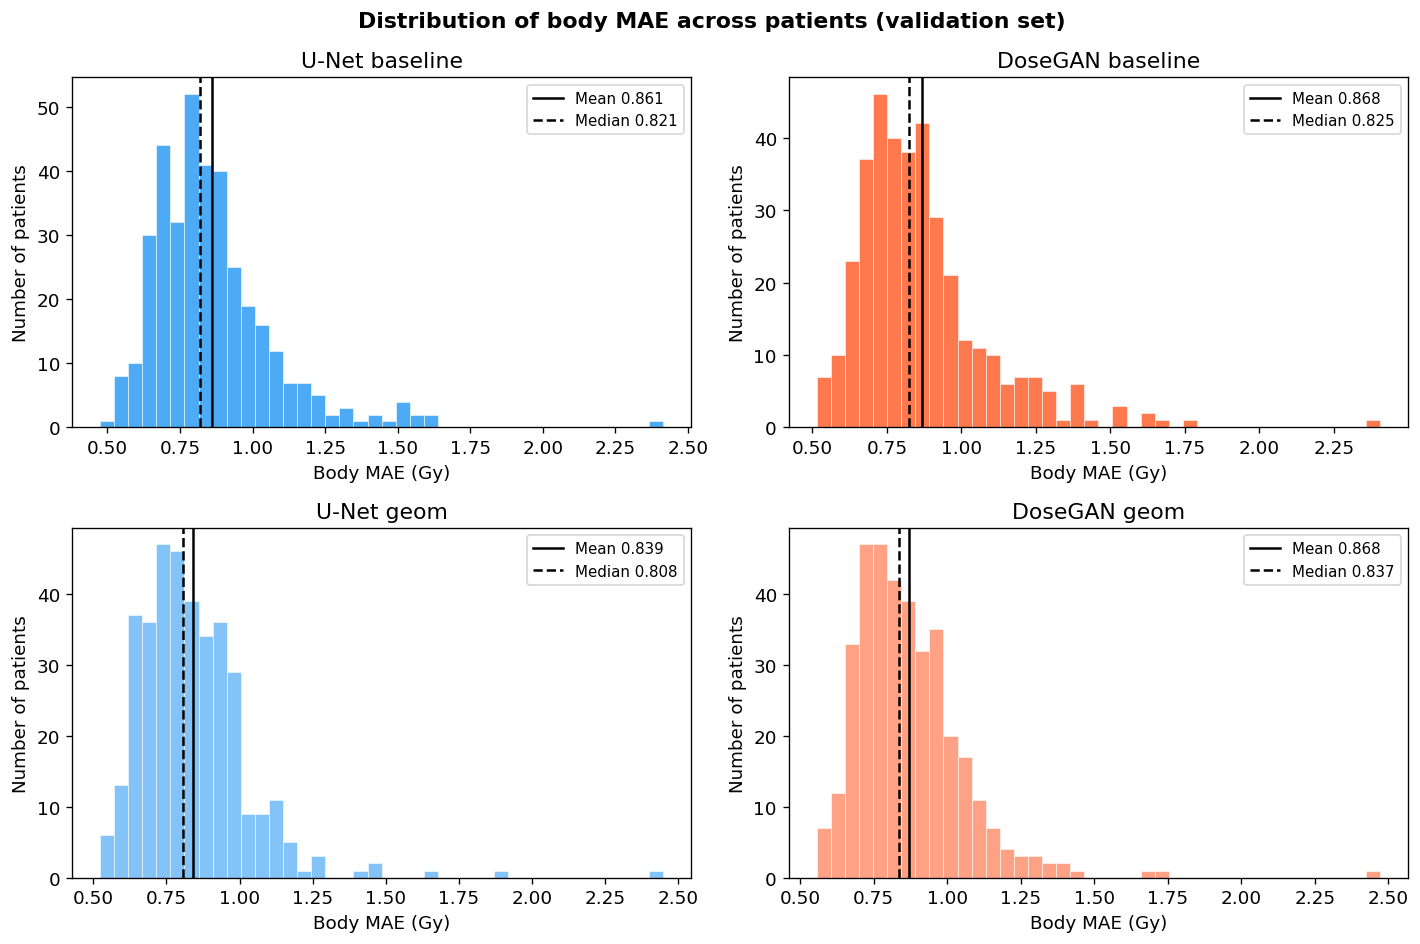

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

for ax, (cond, df) in zip(axes.flat, [('unet_base', unet_base), ('dgan_base', dgan_base),
                                        ('unet_geom', unet_geom), ('dgan_geom', dgan_geom)]):
    vals = df['body_MAE_Gy'].dropna()
    ax.hist(vals, bins=40, color=COLORS[cond], alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.axvline(vals.mean(),   color='black', linewidth=1.5, linestyle='-',  label=f'Mean {vals.mean():.3f}')
    ax.axvline(vals.median(), color='black', linewidth=1.5, linestyle='--', label=f'Median {vals.median():.3f}')
    ax.set_title(LABELS[cond])
    ax.set_xlabel('Body MAE (Gy)')
    ax.set_ylabel('Number of patients')
    ax.legend(fontsize=9)

fig.suptitle('Distribution of body MAE across patients (validation set)', fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Percentile table — shows how heavy the right tail is
pcts = [10, 25, 50, 75, 90, 95, 99]
rows = []
for cond, df in [('unet_base', unet_base), ('dgan_base', dgan_base),
                 ('unet_geom', unet_geom), ('dgan_geom', dgan_geom)]:
    row = {'condition': cond}
    for p in pcts:
        row[f'p{p}'] = round(df['body_MAE_Gy'].quantile(p/100), 3)
    row['max'] = round(df['body_MAE_Gy'].max(), 3)
    rows.append(row)

pd.DataFrame(rows).set_index('condition')

,p10,p25,p50,p75,p90,p95,p99,max
condition,,,,,,,,
unet_base,0.654,0.716,0.821,0.941,1.101,1.242,1.563,2.415
dgan_base,0.646,0.722,0.825,0.949,1.152,1.288,1.641,2.404
unet_geom,0.649,0.715,0.808,0.934,1.036,1.124,1.459,2.448
dgan_geom,0.676,0.740,0.837,0.958,1.080,1.170,1.417,2.472


/scratch-local/akhalil.23432556/claude-77754/ipykernel_502550/3264166513.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True,


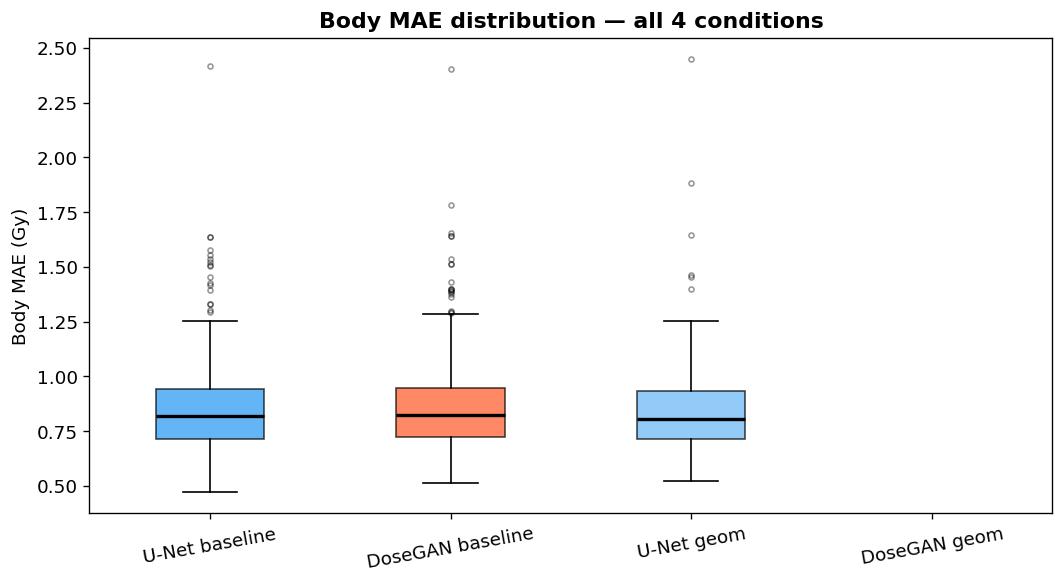

In [6]:
# Box plot: all 4 conditions side by side
fig, ax = plt.subplots(figsize=(9, 5))

data   = [unet_base['body_MAE_Gy'], dgan_base['body_MAE_Gy'],
          unet_geom['body_MAE_Gy'], dgan_geom['body_MAE_Gy']]
labels = [LABELS[c] for c in ['unet_base','dgan_base','unet_geom','dgan_geom']]
colors = [COLORS[c] for c in ['unet_base','dgan_base','unet_geom','dgan_geom']]

bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4),
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Body MAE (Gy)')
ax.set_title('Body MAE distribution — all 4 conditions', fontweight='bold')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

## 3. Cross-model consistency — are the same patients hard for both models?

If U-Net and DoseGAN fail on the same patients, the failures are data-driven (the case is intrinsically difficult), not model-driven.

Pearson r = 0.964  (p = 5.78e-212, n = 367)


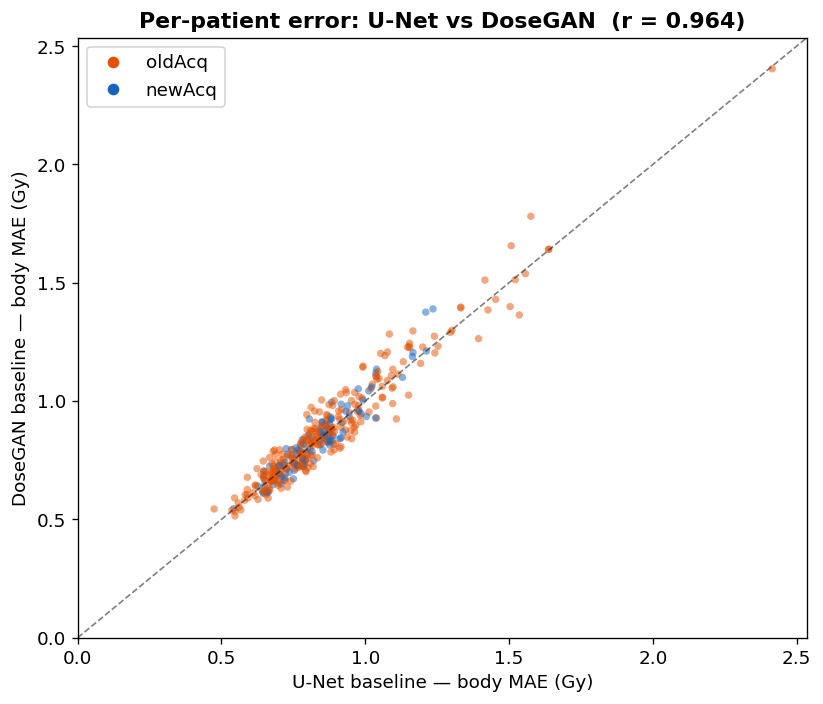

In [7]:
# Merge baseline conditions on patient_id
cross = unet_base[['patient_id','acquisition_group','_fold','body_MAE_Gy']].merge(
    dgan_base[['patient_id','body_MAE_Gy']], on='patient_id', suffixes=('_unet','_dgan'))

r, pval = stats.pearsonr(cross['body_MAE_Gy_unet'], cross['body_MAE_Gy_dgan'])
print(f'Pearson r = {r:.3f}  (p = {pval:.2e}, n = {len(cross)})')

fig, ax = plt.subplots(figsize=(7, 6))

col = cross['acquisition_group'].map({'oldAcq': '#E65100', 'newAcq': '#1565C0'})
ax.scatter(cross['body_MAE_Gy_unet'], cross['body_MAE_Gy_dgan'],
           c=col, alpha=0.5, s=20, linewidths=0)

# Identity line
lim = max(cross[['body_MAE_Gy_unet','body_MAE_Gy_dgan']].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='y = x')

# Legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#E65100', markersize=8, label='oldAcq'),
           Line2D([0],[0], marker='o', color='w', markerfacecolor='#1565C0', markersize=8, label='newAcq')]
ax.legend(handles=handles)

ax.set_xlabel('U-Net baseline — body MAE (Gy)')
ax.set_ylabel('DoseGAN baseline — body MAE (Gy)')
ax.set_title(f'Per-patient error: U-Net vs DoseGAN  (r = {r:.3f})', fontweight='bold')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

In [8]:
# Which patients are hard for BOTH models?
cross['mean_err'] = (cross['body_MAE_Gy_unet'] + cross['body_MAE_Gy_dgan']) / 2
print('Top 20 patients hardest for both models:')
display(cross.nlargest(20, 'mean_err')[['patient_id','acquisition_group','_fold',
                                         'body_MAE_Gy_unet','body_MAE_Gy_dgan','mean_err']]
        .reset_index(drop=True))

Top 20 patients hardest for both models:


,patient_id,acquisition_group,_fold,body_MAE_Gy_unet,body_MAE_Gy_dgan,mean_err
0,oldAcq_bfc95ad92...,oldAcq,1,2.415353,2.404441,2.409897
1,oldAcq_701d65974...,oldAcq,2,1.575885,1.780843,1.678364
2,oldAcq_12f323c77...,oldAcq,3,1.638135,1.641572,1.639854
3,oldAcq_de7019252...,oldAcq,1,1.637350,1.640761,1.639056
4,oldAcq_2289c655a...,oldAcq,2,1.507495,1.656330,1.581912
5,oldAcq_110e21039...,oldAcq,0,1.556611,1.538344,1.547477
6,oldAcq_f26755c8f...,oldAcq,3,1.521659,1.513139,1.517399
7,oldAcq_9934f4b8a...,oldAcq,4,1.416281,1.511294,1.463788
8,oldAcq_375a88267...,oldAcq,0,1.503674,1.399341,1.451508
9,oldAcq_3bee8a3ca...,oldAcq,3,1.535809,1.363784,1.449796


## 4. oldAcq vs newAcq — acquisition group deep-dive

oldAcq and newAcq scans differ in scanner protocol. Is the error gap driven by a few extreme outliers, or is oldAcq uniformly harder?

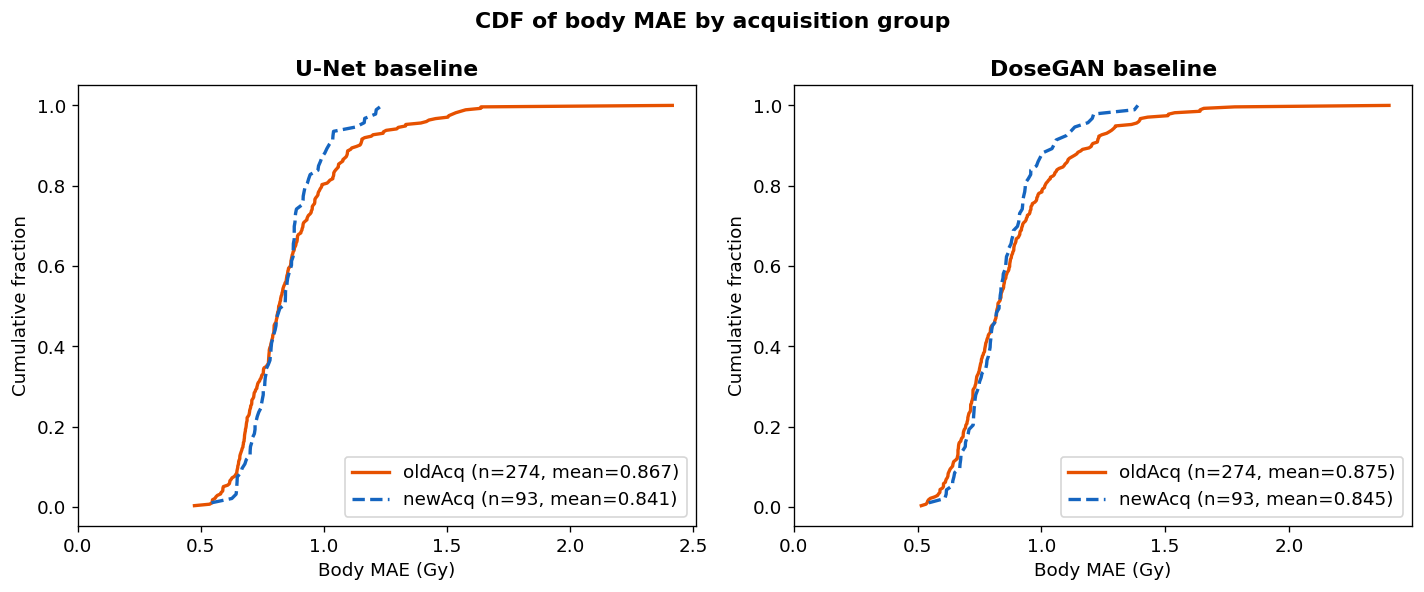

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (cond, df) in zip(axes, [('unet_base', unet_base), ('dgan_base', dgan_base)]):
    for grp, color, ls in [('oldAcq', '#E65100', '-'), ('newAcq', '#1565C0', '--')]:
        vals = df[df['acquisition_group'] == grp]['body_MAE_Gy'].sort_values()
        cdf  = np.arange(1, len(vals)+1) / len(vals)
        ax.plot(vals, cdf, color=color, linestyle=ls, linewidth=2,
                label=f'{grp} (n={len(vals)}, mean={vals.mean():.3f})')
    ax.set_xlabel('Body MAE (Gy)')
    ax.set_ylabel('Cumulative fraction')
    ax.set_title(f'{LABELS[cond]}', fontweight='bold')
    ax.legend()
    ax.set_xlim(0)

fig.suptitle('CDF of body MAE by acquisition group', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Mann-Whitney test: is the oldAcq/newAcq difference statistically significant?
print('Mann-Whitney U test: oldAcq vs newAcq body_MAE\n')
for cond, df in [('unet_base', unet_base), ('dgan_base', dgan_base),
                 ('unet_geom', unet_geom), ('dgan_geom', dgan_geom)]:
    old = df[df['acquisition_group']=='oldAcq']['body_MAE_Gy']
    new = df[df['acquisition_group']=='newAcq']['body_MAE_Gy']
    u, p = stats.mannwhitneyu(old, new, alternative='two-sided')
    print(f'{cond}: oldAcq mean={old.mean():.3f} p90={old.quantile(0.9):.3f}  '
          f'newAcq mean={new.mean():.3f} p90={new.quantile(0.9):.3f}  '
          f'MWU p={p:.4f}')

Mann-Whitney U test: oldAcq vs newAcq body_MAE

unet_base: oldAcq mean=0.867 p90=1.143  newAcq mean=0.841 p90=1.020  MWU p=0.8943
dgan_base: oldAcq mean=0.875 p90=1.203  newAcq mean=0.845 p90=1.050  MWU p=0.8934
unet_geom: oldAcq mean=0.845 p90=1.066  newAcq mean=0.823 p90=0.986  MWU p=0.7925
dgan_geom: oldAcq mean=0.871 p90=1.077  newAcq mean=0.861 p90=1.082  MWU p=0.8889


/scratch-local/akhalil.23432556/claude-77754/ipykernel_502550/1928550384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[c] for c in plot_df['condition'].unique()])


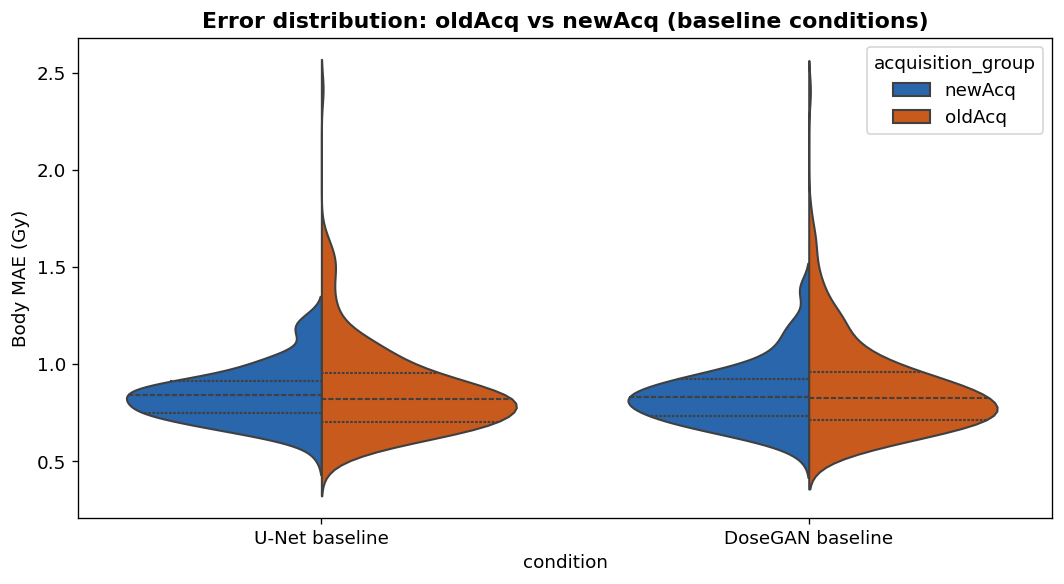

In [11]:
# Violin plot: error distribution within each acquisition group across conditions
plot_df = all_df[all_df['condition'].isin(['unet_base','dgan_base'])].copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=plot_df, x='condition', y='body_MAE_Gy', hue='acquisition_group',
               split=True, inner='quartile', palette={'oldAcq':'#E65100','newAcq':'#1565C0'},
               ax=ax)
ax.set_xticklabels([LABELS[c] for c in plot_df['condition'].unique()])
ax.set_ylabel('Body MAE (Gy)')
ax.set_title('Error distribution: oldAcq vs newAcq (baseline conditions)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Structure-level error breakdown

Where does the error live — in the target (PTV) or in the organs at risk (rectum, bladder)? And does body_MAE correlate with structure-specific errors?

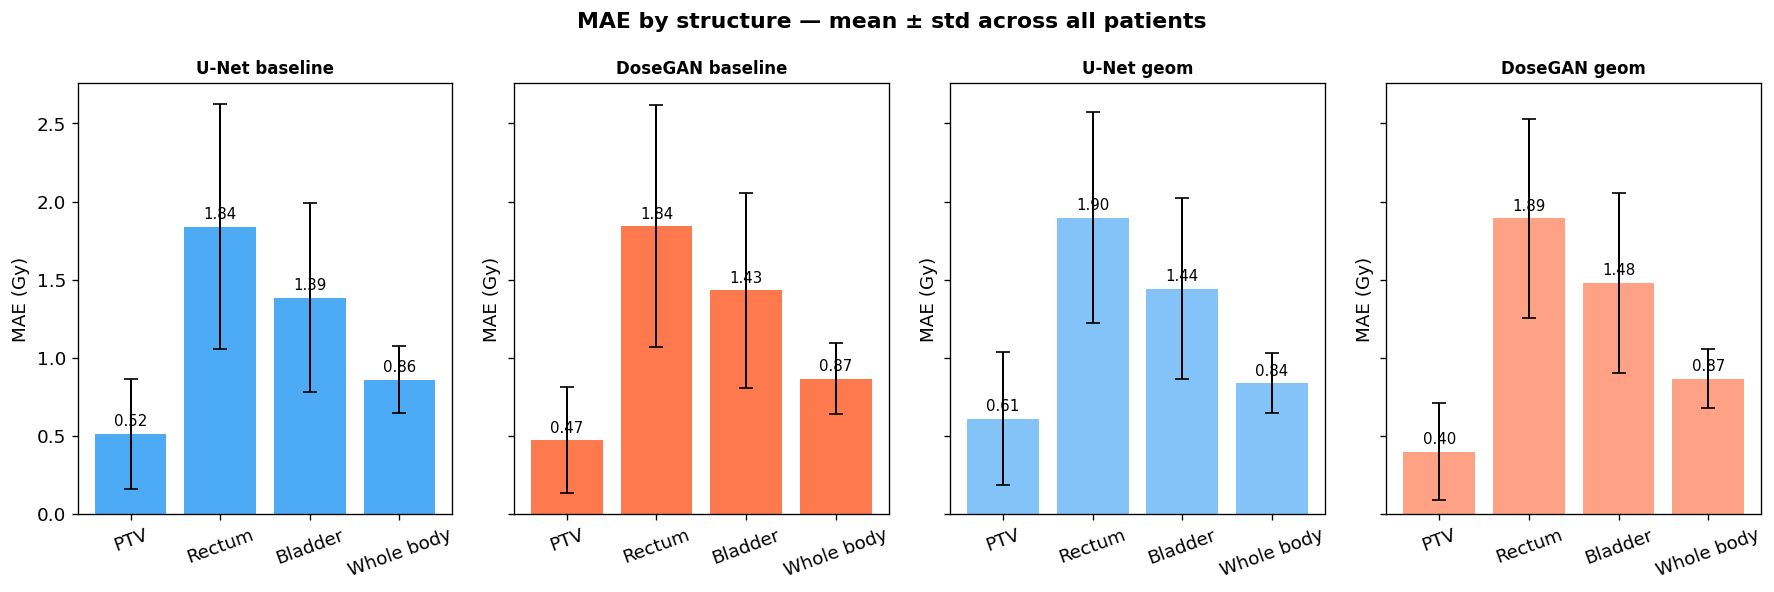

In [12]:
struct_cols  = ['ptv_MAE_Gy', 'rectum_MAE_Gy', 'bladder_MAE_Gy', 'body_MAE_Gy']
struct_names = ['PTV', 'Rectum', 'Bladder', 'Whole body']

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=True)

for ax, (cond, df) in zip(axes, [('unet_base', unet_base), ('dgan_base', dgan_base),
                                   ('unet_geom', unet_geom), ('dgan_geom', dgan_geom)]):
    means = [df[c].mean() for c in struct_cols]
    stds  = [df[c].std()  for c in struct_cols]
    bars  = ax.bar(struct_names, means, yerr=stds, color=COLORS[cond],
                   alpha=0.8, capsize=4, error_kw={'linewidth':1.2})
    ax.set_title(LABELS[cond], fontsize=10, fontweight='bold')
    ax.set_ylabel('MAE (Gy)')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('MAE by structure — mean ± std across all patients', fontweight='bold')
plt.tight_layout()
plt.show()

Pearson r with body_MAE_Gy (U-Net baseline):

  PTV       : r = 0.051  (p = 3.310e-01)
  Rectum    : r = 0.191  (p = 2.293e-04)
  Bladder   : r = 0.245  (p = 2.097e-06)

--- scatter plots below ---


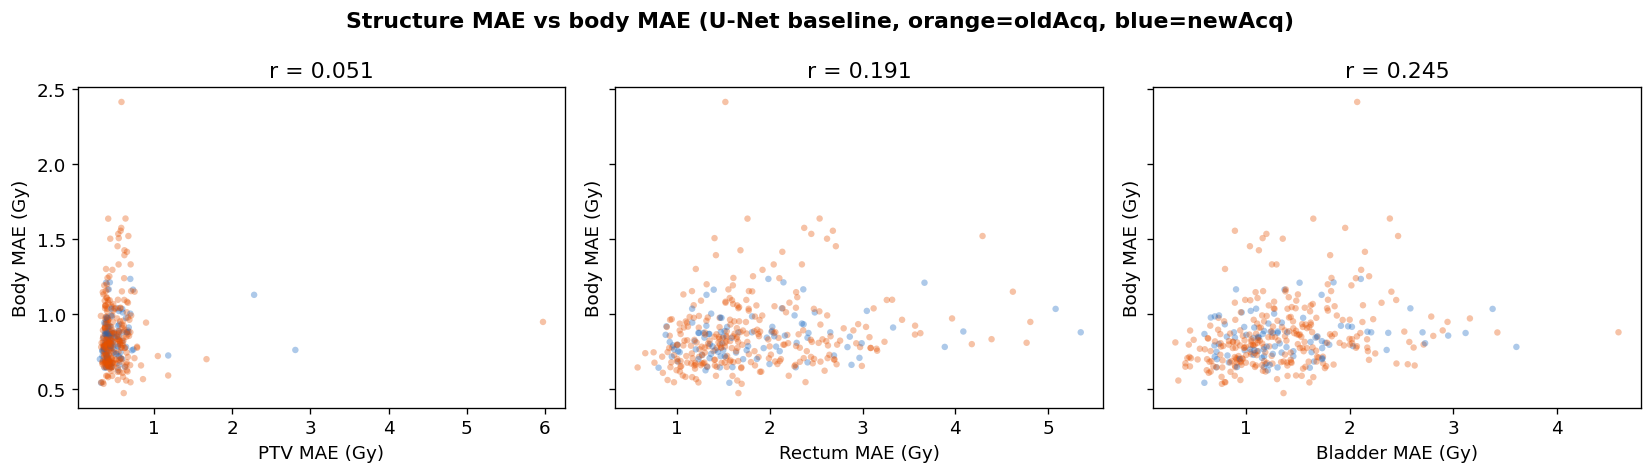

In [13]:
# Correlation of each structure MAE with body MAE
print('Pearson r with body_MAE_Gy (U-Net baseline):\n')
for col, name in zip(struct_cols[:-1], struct_names[:-1]):
    r, p = stats.pearsonr(unet_base[col].dropna(), unet_base['body_MAE_Gy'].dropna())
    print(f'  {name:10s}: r = {r:.3f}  (p = {p:.3e})')

print('\n--- scatter plots below ---')

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col, name in zip(axes, struct_cols[:-1], struct_names[:-1]):
    ax.scatter(unet_base[col], unet_base['body_MAE_Gy'],
               c=unet_base['acquisition_group'].map({'oldAcq':'#E65100','newAcq':'#1565C0'}),
               alpha=0.35, s=15, linewidths=0)
    r, _ = stats.pearsonr(unet_base[col].dropna(), unet_base['body_MAE_Gy'].dropna())
    ax.set_xlabel(f'{name} MAE (Gy)')
    ax.set_ylabel('Body MAE (Gy)')
    ax.set_title(f'r = {r:.3f}')

fig.suptitle('Structure MAE vs body MAE (U-Net baseline, orange=oldAcq, blue=newAcq)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Boundary MAE vs interior MAE for each structure
print('Boundary vs interior MAE comparison (U-Net baseline, mean Gy):\n')
for struct in ['ptv', 'rectum', 'bladder']:
    interior = unet_base[f'{struct}_MAE_Gy'].mean()
    boundary = unet_base[f'boundary_MAE_{struct}_Gy'].mean()
    ratio    = boundary / interior
    print(f'  {struct:10s}: interior={interior:.3f} Gy   boundary={boundary:.3f} Gy   ratio={ratio:.2f}x')

Boundary vs interior MAE comparison (U-Net baseline, mean Gy):

  ptv       : interior=0.515 Gy   boundary=1.577 Gy   ratio=3.06x
  rectum    : interior=1.840 Gy   boundary=1.381 Gy   ratio=0.75x
  bladder   : interior=1.386 Gy   boundary=1.107 Gy   ratio=0.80x


## 6. Signed bias — systematic over/under-prediction

`_diff = pred - true`. Positive = over-prediction, negative = under-prediction.

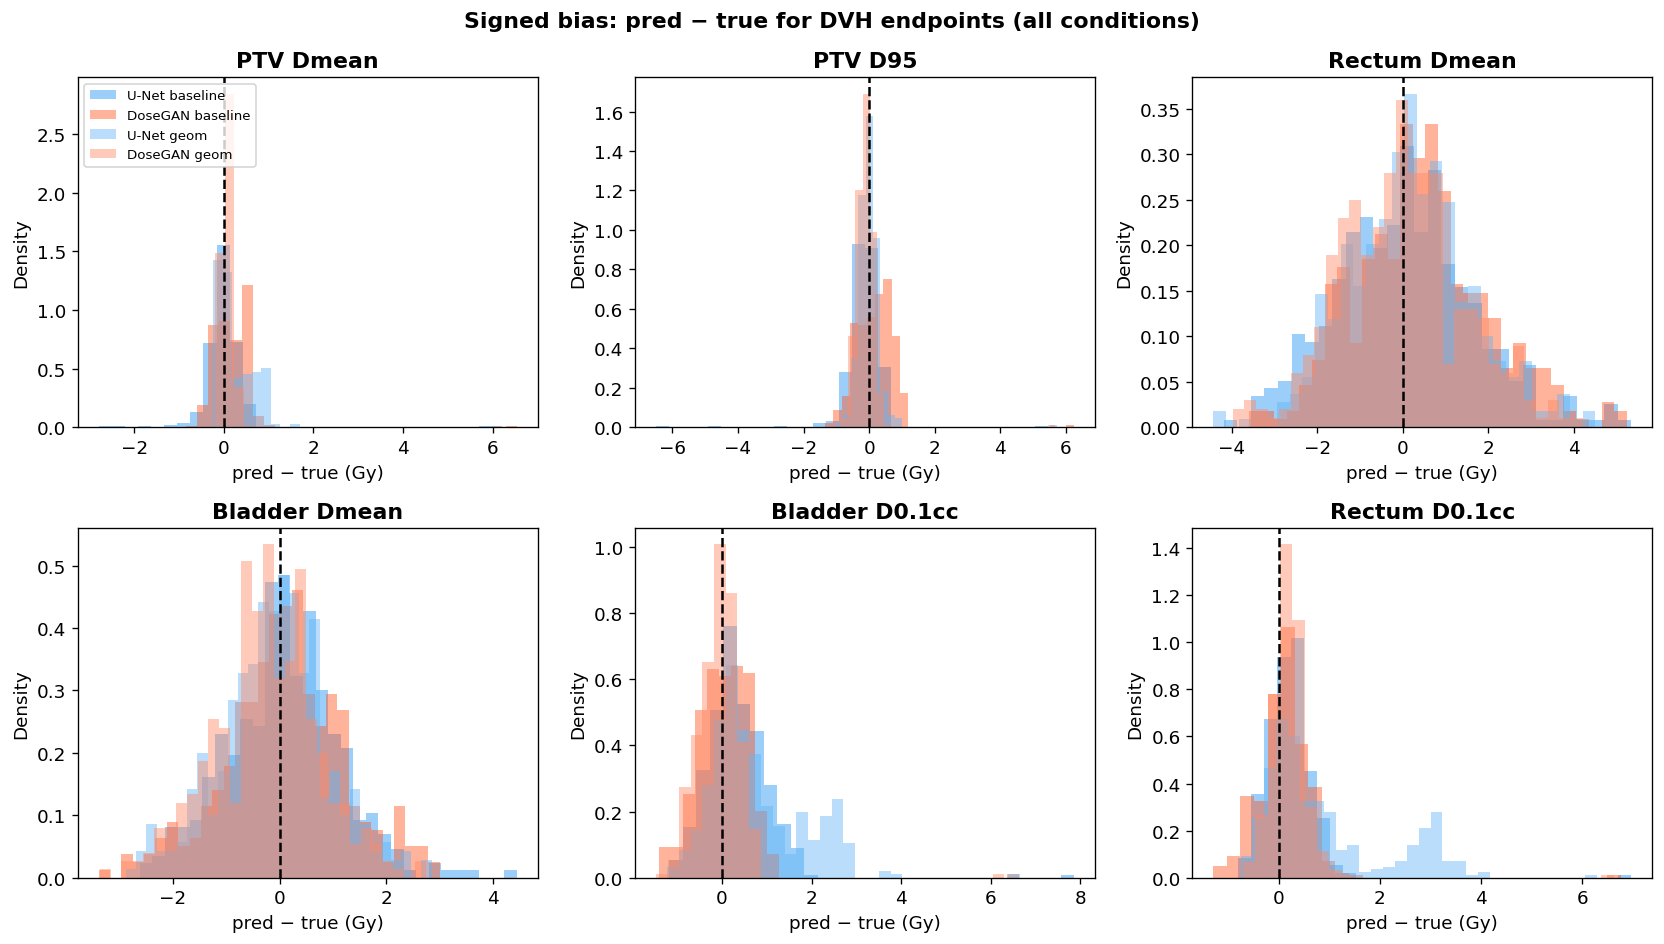

In [15]:
bias_cols = {
    'ptv_Dmean_diff':    'PTV Dmean',
    'ptv_D95_diff':      'PTV D95',
    'rectum_Dmean_diff': 'Rectum Dmean',
    'bladder_Dmean_diff':'Bladder Dmean',
    'bladder_D01cc_diff':'Bladder D0.1cc',
    'rectum_D01cc_diff': 'Rectum D0.1cc',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (col, title) in zip(axes.flat, bias_cols.items()):
    for cond, df, color in [('unet_base', unet_base, COLORS['unet_base']),
                             ('dgan_base', dgan_base, COLORS['dgan_base']),
                             ('unet_geom', unet_geom, COLORS['unet_geom']),
                             ('dgan_geom', dgan_geom, COLORS['dgan_geom'])]:
        vals = df[col].dropna()
        ax.hist(vals, bins=30, color=color, alpha=0.45, label=LABELS[cond], density=True)
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('pred − true (Gy)')
    ax.set_ylabel('Density')

axes.flat[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Signed bias: pred − true for DVH endpoints (all conditions)', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Mean signed bias table and % of patients over-predicting
print(f'{"Metric":<20} {"unet_base":>18} {"dgan_base":>18} {"unet_geom":>18} {"dgan_geom":>18}')
print('-' * 95)
for col, name in bias_cols.items():
    row = f'{name:<20}'
    for df in [unet_base, dgan_base, unet_geom, dgan_geom]:
        v   = df[col].dropna()
        pct = (v > 0).mean() * 100
        row += f'  {v.mean():+.3f} ({pct:.0f}% over)'
    print(row)

Metric                        unet_base          dgan_base          unet_geom          dgan_geom
-----------------------------------------------------------------------------------------------
PTV Dmean             -0.020 (46% over)  +0.179 (67% over)  +0.271 (63% over)  +0.094 (75% over)
PTV D95               -0.165 (34% over)  +0.183 (61% over)  -0.003 (48% over)  -0.116 (30% over)
Rectum Dmean          +0.061 (52% over)  +0.459 (62% over)  +0.198 (57% over)  -0.056 (48% over)
Bladder Dmean         +0.096 (55% over)  +0.092 (55% over)  -0.095 (47% over)  -0.268 (41% over)
Bladder D0.1cc        +0.347 (71% over)  +0.051 (54% over)  +0.786 (79% over)  -0.066 (45% over)
Rectum D0.1cc         +0.216 (70% over)  +0.093 (60% over)  +0.922 (79% over)  +0.205 (77% over)


## 7. Worst-patient characterisation

Take the patients with the highest error and look at what makes them hard. All 20 worst cases are oldAcq — is this because oldAcq patients are systematically harder, or are there specific sub-groups?

In [17]:
# Top 30 worst patients by U-Net baseline body_MAE
worst30 = unet_base.nlargest(30, 'body_MAE_Gy')[[
    'patient_id','acquisition_group','_fold',
    'body_MAE_Gy','ptv_MAE_Gy','rectum_MAE_Gy','bladder_MAE_Gy',
    'ptv_D95_diff','rectum_Dmean_diff','bladder_Dmean_diff'
]].reset_index(drop=True)

print(f'Acquisition group breakdown in top 30:')
print(worst30['acquisition_group'].value_counts())
print(f'\nFold breakdown in top 30:')
print(worst30['_fold'].value_counts().sort_index())
print()
display(worst30)

Acquisition group breakdown in top 30:
acquisition_group
oldAcq    25
newAcq     5
Name: count, dtype: int64

Fold breakdown in top 30:
_fold
0    6
1    9
2    7
3    6
4    2
Name: count, dtype: int64



,patient_id,acquisition_group,_fold,body_MAE_Gy,ptv_MAE_Gy,rectum_MAE_Gy,bladder_MAE_Gy,ptv_D95_diff,rectum_Dmean_diff,bladder_Dmean_diff
0,oldAcq_bfc95ad92...,oldAcq,1,2.415353,0.584349,1.519476,2.072494,0.082600,0.658377,-1.350309
1,oldAcq_12f323c77...,oldAcq,3,1.638135,0.635757,2.536253,2.387385,0.505852,-2.025768,-1.906700
2,oldAcq_de7019252...,oldAcq,1,1.637350,0.414652,1.758169,1.649327,-0.066612,0.383238,-1.145353
3,oldAcq_701d65974...,oldAcq,2,1.575885,0.581747,2.370203,1.956846,-0.204941,-2.230303,-1.512891
4,oldAcq_110e21039...,oldAcq,0,1.556611,0.573583,2.679222,0.893590,-0.124306,2.025665,-0.421370
5,oldAcq_3bee8a3ca...,oldAcq,3,1.535809,0.543492,2.446588,1.197279,0.106361,-2.069766,0.168901
6,oldAcq_f26755c8f...,oldAcq,3,1.521659,0.672593,4.294060,2.466728,0.399532,-4.191438,-2.015440
7,oldAcq_2289c655a...,oldAcq,2,1.507495,0.549934,1.402366,1.160953,0.029980,-1.037357,0.613474
8,oldAcq_375a88267...,oldAcq,0,1.503674,0.440902,2.616323,1.354933,0.070496,-1.728788,-0.240280
9,oldAcq_34467475b...,oldAcq,0,1.453553,0.533884,2.711476,1.038406,-0.030201,-2.301050,-0.128059


In [18]:
# Error profile of worst vs best patients
n_tail = 30
worst_ids = unet_base.nlargest(n_tail, 'body_MAE_Gy')['patient_id']
best_ids  = unet_base.nsmallest(n_tail, 'body_MAE_Gy')['patient_id']

worst_df = unet_base[unet_base['patient_id'].isin(worst_ids)]
best_df  = unet_base[unet_base['patient_id'].isin(best_ids)]

compare_cols = ['body_MAE_Gy','ptv_MAE_Gy','rectum_MAE_Gy','bladder_MAE_Gy',
                'boundary_MAE_ptv_Gy','boundary_MAE_rectum_Gy','boundary_MAE_bladder_Gy',
                'ptv_D95_diff','rectum_Dmean_diff','bladder_Dmean_diff']

rows = []
for col in compare_cols:
    rows.append({'metric': col,
                 'worst_30_mean': worst_df[col].mean(),
                 'best_30_mean':  best_df[col].mean(),
                 'ratio': worst_df[col].abs().mean() / (best_df[col].abs().mean() + 1e-9)})

comp = pd.DataFrame(rows).round(3)
display(comp)

,metric,worst_30_mean,best_30_mean,ratio
0,body_MAE_Gy,1.381,0.596,2.316
1,ptv_MAE_Gy,0.531,0.521,1.018
2,rectum_MAE_Gy,2.052,1.431,1.433
3,bladder_MAE_Gy,1.624,1.064,1.525
4,boundary_MAE_ptv_Gy,1.549,1.435,1.079
5,boundary_MAE_rec...,1.705,1.098,1.554
6,boundary_MAE_bla...,1.387,0.830,1.672
7,ptv_D95_diff,0.026,-0.284,0.602
8,rectum_Dmean_diff,-0.628,-0.149,1.682
9,bladder_Dmean_diff,-0.428,-0.089,1.774


## 8. Anatomy features from pickles — structure volumes vs error

Do patients with larger bladders or rectums have worse predictions? Does PTV volume or shape predict error?  
**Note:** This cell loads 367 pickles and takes ~1–2 minutes.

In [19]:
VOXEL_MM = 1.5  # isotropic spacing
VOXEL_VOL_CC = (VOXEL_MM ** 3) / 1000  # cm³ per voxel

anatomy = []
for pkl_path in sorted(glob.glob(PICKLE_DIR + '*.pkl')):
    with open(pkl_path, 'rb') as f:
        d = pickle.load(f)
    pid = d['patient_id']
    ptv  = d['ptv_mask'].astype(bool)
    rect = d['rectum_mask'].astype(bool)
    blad = d['bladder_mask'].astype(bool)
    # volumes in cm³
    ptv_vol  = ptv.sum()  * VOXEL_VOL_CC
    rect_vol = rect.sum() * VOXEL_VOL_CC
    blad_vol = blad.sum() * VOXEL_VOL_CC
    # PTV z-extent (superior-inferior span in mm)
    z_idx = np.where(ptv.any(axis=(1,2)))[0]
    ptv_z_span = (z_idx.max() - z_idx.min() + 1) * VOXEL_MM if len(z_idx) > 0 else 0
    anatomy.append({'patient_id': pid,
                    'ptv_vol_cc': ptv_vol,
                    'rectum_vol_cc': rect_vol,
                    'bladder_vol_cc': blad_vol,
                    'ptv_z_span_mm': ptv_z_span})

anat_df = pd.DataFrame(anatomy)
print(f'Loaded anatomy for {len(anat_df)} patients')
display(anat_df.describe().round(1))

Loaded anatomy for 367 patients


,ptv_vol_cc,rectum_vol_cc,bladder_vol_cc,ptv_z_span_mm
count,367.0,367.0,367.0,367.0
mean,133.4,65.0,157.5,63.4
std,38.2,22.1,97.2,8.2
min,63.8,24.1,33.2,48.0
25%,105.7,50.5,89.6,57.0
50%,126.2,60.0,130.7,63.0
75%,154.8,74.8,194.5,67.5
max,313.9,177.3,573.4,97.5


Merged: 367 patients


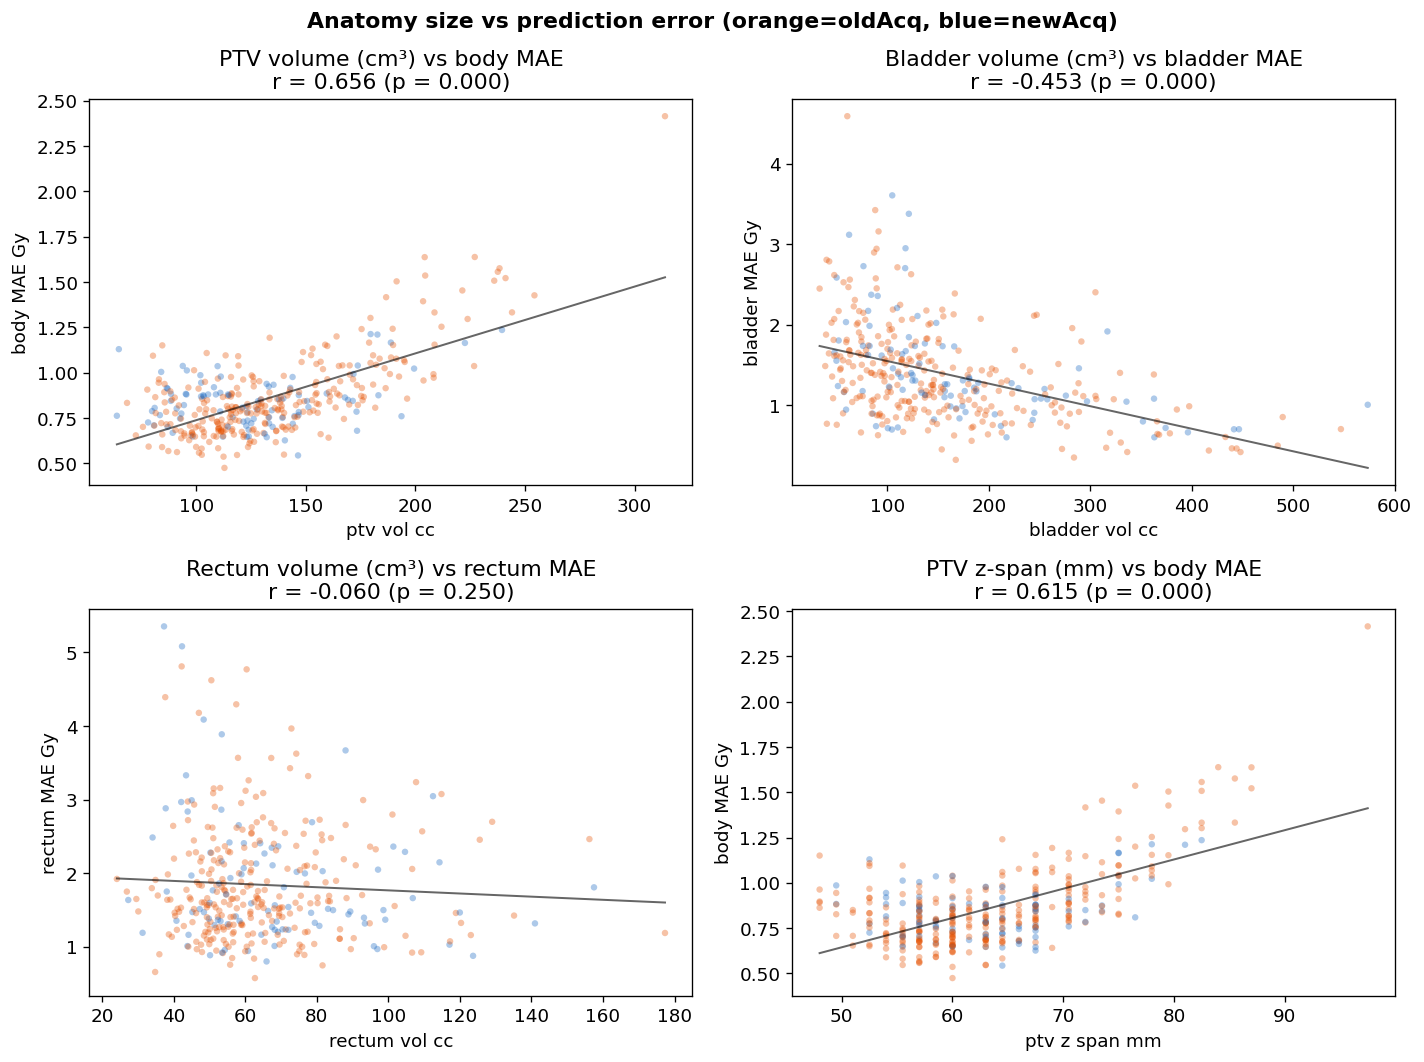

In [20]:
# Merge anatomy with U-Net baseline errors
merged = unet_base.merge(anat_df, on='patient_id')
print(f'Merged: {len(merged)} patients')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

pairs = [
    ('ptv_vol_cc',     'body_MAE_Gy',      'PTV volume (cm³) vs body MAE'),
    ('bladder_vol_cc', 'bladder_MAE_Gy',   'Bladder volume (cm³) vs bladder MAE'),
    ('rectum_vol_cc',  'rectum_MAE_Gy',    'Rectum volume (cm³) vs rectum MAE'),
    ('ptv_z_span_mm',  'body_MAE_Gy',      'PTV z-span (mm) vs body MAE'),
]

for ax, (x, y, title) in zip(axes.flat, pairs):
    col = merged['acquisition_group'].map({'oldAcq':'#E65100','newAcq':'#1565C0'})
    ax.scatter(merged[x], merged[y], c=col, alpha=0.35, s=15, linewidths=0)
    r, p = stats.pearsonr(merged[x], merged[y])
    # regression line
    m_coef, b_coef = np.polyfit(merged[x], merged[y], 1)
    xline = np.linspace(merged[x].min(), merged[x].max(), 100)
    ax.plot(xline, m_coef*xline + b_coef, 'k-', linewidth=1.2, alpha=0.6)
    ax.set_xlabel(x.replace('_', ' '))
    ax.set_ylabel(y.replace('_', ' '))
    ax.set_title(f'{title}\nr = {r:.3f} (p = {p:.3f})')

fig.suptitle('Anatomy size vs prediction error (orange=oldAcq, blue=newAcq)', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Anatomy features for worst vs best 30 patients
worst_anat = merged[merged['patient_id'].isin(worst_ids)]
best_anat  = merged[merged['patient_id'].isin(best_ids)]

header = '{:<22} {:>16} {:>16} {:>12}'.format('Anatomy feature', 'Worst 30 mean', 'Best 30 mean', 'Difference')
print(header)
print('-' * 70)
for col in ['ptv_vol_cc','bladder_vol_cc','rectum_vol_cc','ptv_z_span_mm']:
    wm = worst_anat[col].mean()
    bm = best_anat[col].mean()
    print('{:<22} {:>16.1f} {:>16.1f} {:>+12.1f}'.format(col, wm, bm, wm - bm))

Anatomy feature           Worst 30 mean     Best 30 mean   Difference
----------------------------------------------------------------------
ptv_vol_cc                        208.3            113.9        +94.4
bladder_vol_cc                    139.2            152.5        -13.3
rectum_vol_cc                      68.5             60.4         +8.0
ptv_z_span_mm                      78.8             60.1        +18.7


## 9. Geom channels — patient-level delta

Do geometric channels consistently help, or do they help some patients and hurt others? Where is the regression concentrated?

In [22]:
# Compute per-patient delta: geom - baseline (negative = improvement)
un_delta = unet_base[['patient_id','acquisition_group','body_MAE_Gy']].merge(
    unet_geom[['patient_id','body_MAE_Gy']], on='patient_id', suffixes=('_base','_geom'))
un_delta['delta'] = un_delta['body_MAE_Gy_geom'] - un_delta['body_MAE_Gy_base']

dg_delta = dgan_base[['patient_id','acquisition_group','body_MAE_Gy']].merge(
    dgan_geom[['patient_id','body_MAE_Gy']], on='patient_id', suffixes=('_base','_geom'))
dg_delta['delta'] = dg_delta['body_MAE_Gy_geom'] - dg_delta['body_MAE_Gy_base']

print('U-Net geom delta (geom − baseline):')
print(f'  Improves: {(un_delta.delta<0).sum()}/{len(un_delta)} patients '
      f'({(un_delta.delta<0).mean()*100:.0f}%)')
print(f'  Mean delta: {un_delta.delta.mean():+.4f} Gy')
print(f'  Max improvement: {un_delta.delta.min():+.3f} Gy')
print(f'  Max regression:  {un_delta.delta.max():+.3f} Gy')

print('\nDoseGAN geom delta (geom − baseline):')
print(f'  Improves: {(dg_delta.delta<0).sum()}/{len(dg_delta)} patients '
      f'({(dg_delta.delta<0).mean()*100:.0f}%)')
print(f'  Mean delta: {dg_delta.delta.mean():+.4f} Gy')
print(f'  Max improvement: {dg_delta.delta.min():+.3f} Gy')
print(f'  Max regression:  {dg_delta.delta.max():+.3f} Gy')

U-Net geom delta (geom − baseline):
  Improves: 195/367 patients (53%)
  Mean delta: -0.0212 Gy
  Max improvement: -0.467 Gy
  Max regression:  +0.423 Gy

DoseGAN geom delta (geom − baseline):
  Improves: 153/367 patients (42%)
  Mean delta: +0.0006 Gy
  Max improvement: -0.588 Gy
  Max regression:  +0.523 Gy


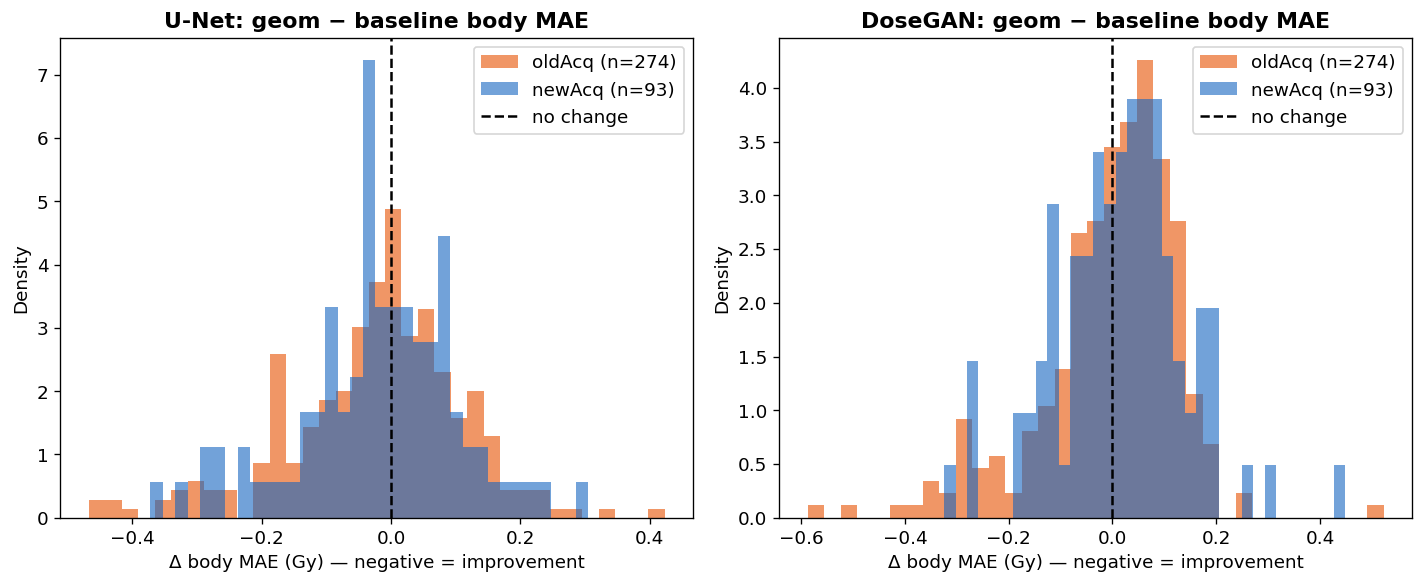

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (delta_df, title) in zip(axes, [
        (un_delta, 'U-Net: geom − baseline body MAE'),
        (dg_delta, 'DoseGAN: geom − baseline body MAE')]):
    old = delta_df[delta_df['acquisition_group']=='oldAcq']['delta']
    new = delta_df[delta_df['acquisition_group']=='newAcq']['delta']
    ax.hist(old, bins=35, color='#E65100', alpha=0.6, label=f'oldAcq (n={len(old)})', density=True)
    ax.hist(new, bins=35, color='#1565C0', alpha=0.6, label=f'newAcq (n={len(new)})', density=True)
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='no change')
    ax.set_xlabel('Δ body MAE (Gy) — negative = improvement')
    ax.set_ylabel('Density')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

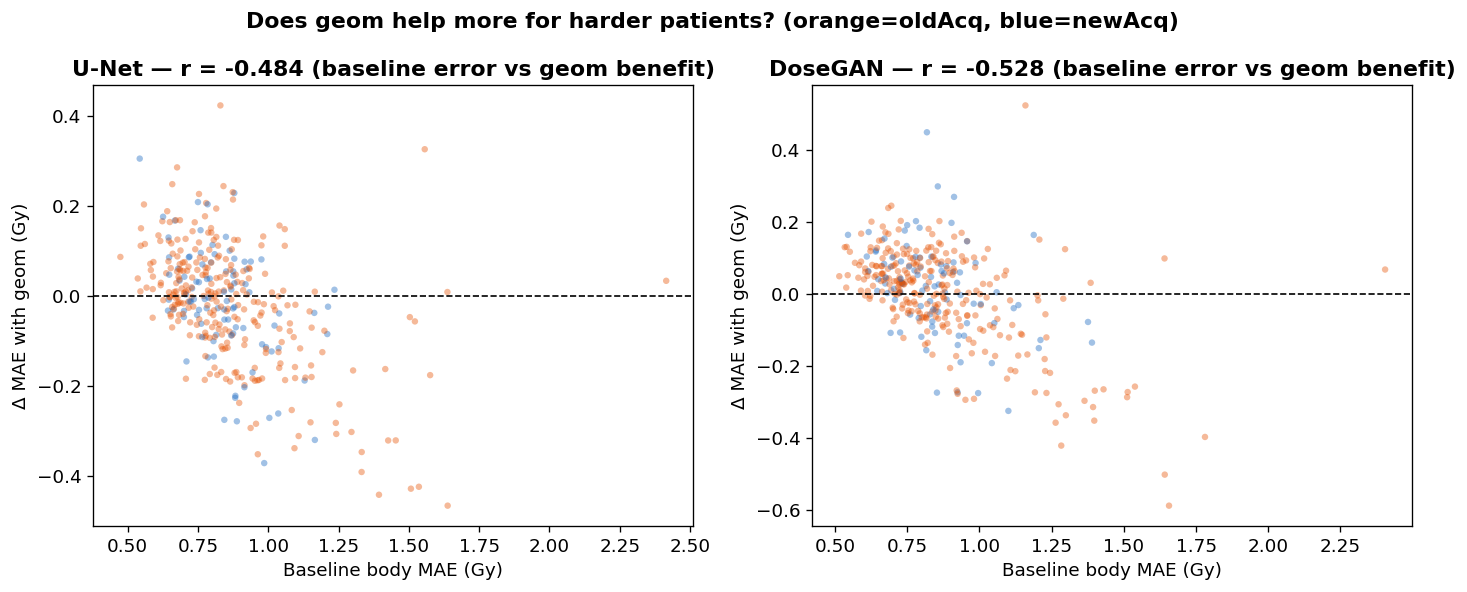

In [24]:
# Does baseline error predict whether geom helps?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (delta_df, title) in zip(axes, [
        (un_delta, 'U-Net'),
        (dg_delta, 'DoseGAN')]):
    col = delta_df['acquisition_group'].map({'oldAcq':'#E65100','newAcq':'#1565C0'})
    ax.scatter(delta_df['body_MAE_Gy_base'], delta_df['delta'],
               c=col, alpha=0.4, s=15, linewidths=0)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    r, p = stats.pearsonr(delta_df['body_MAE_Gy_base'], delta_df['delta'])
    ax.set_xlabel('Baseline body MAE (Gy)')
    ax.set_ylabel('Δ MAE with geom (Gy)')
    ax.set_title(f'{title} — r = {r:.3f} (baseline error vs geom benefit)', fontweight='bold')

fig.suptitle('Does geom help more for harder patients? (orange=oldAcq, blue=newAcq)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Per-fold variance

Fold 1 is consistently the worst across all conditions. What is different about the patients assigned to fold 1?

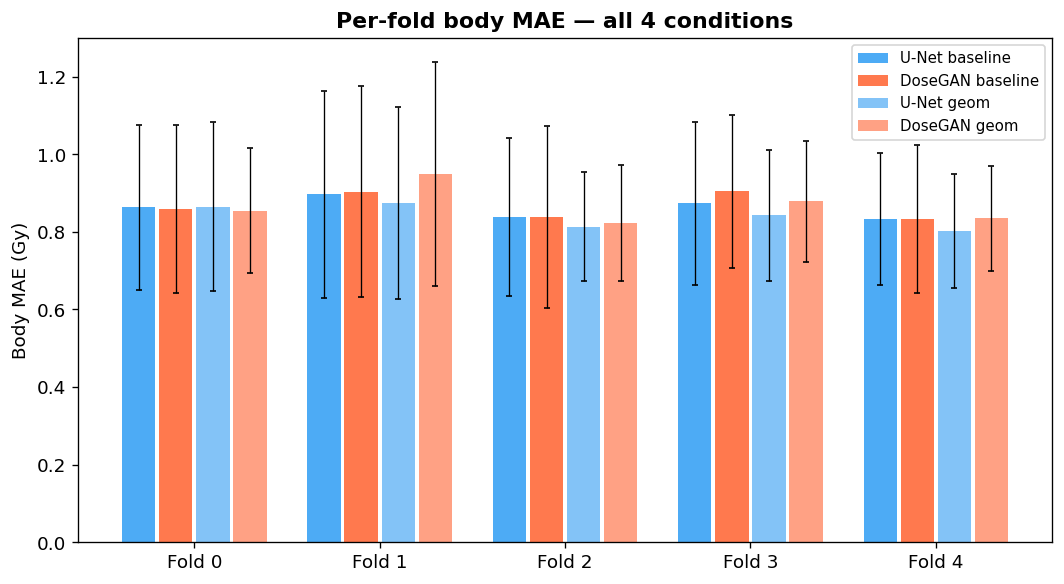

In [25]:
# Per-fold body MAE for all 4 conditions
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(5)
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for offset, (cond, df) in zip(offsets, [('unet_base', unet_base), ('dgan_base', dgan_base),
                                          ('unet_geom', unet_geom), ('dgan_geom', dgan_geom)]):
    fold_means = df.groupby('_fold')['body_MAE_Gy'].mean()
    fold_stds  = df.groupby('_fold')['body_MAE_Gy'].std()
    ax.bar(x + offset*width, fold_means.values, width=width*0.9,
           color=COLORS[cond], alpha=0.8, label=LABELS[cond],
           yerr=fold_stds.values, capsize=2, error_kw={'linewidth':0.8})

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(5)])
ax.set_ylabel('Body MAE (Gy)')
ax.set_title('Per-fold body MAE — all 4 conditions', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [26]:
# Fold 1 characterisation: acquisition group mix and anatomy
fold1 = unet_base[unet_base['_fold'] == 1]
other = unet_base[unet_base['_fold'] != 1]

print('Fold 1 vs other folds (U-Net baseline):')
print(f'  Fold 1  body_MAE: {fold1.body_MAE_Gy.mean():.3f} ± {fold1.body_MAE_Gy.std():.3f} Gy  (n={len(fold1)})')
print(f'  Others  body_MAE: {other.body_MAE_Gy.mean():.3f} ± {other.body_MAE_Gy.std():.3f} Gy  (n={len(other)})')
print()
print('Fold 1 acquisition group mix:')
print(fold1['acquisition_group'].value_counts())
print(f'  oldAcq fraction: {(fold1.acquisition_group=="oldAcq").mean()*100:.1f}%')
print()
print('All folds acquisition group mix:')
print(unet_base.groupby('_fold')['acquisition_group'].value_counts().unstack(fill_value=0))

Fold 1 vs other folds (U-Net baseline):
  Fold 1  body_MAE: 0.896 ± 0.267 Gy  (n=74)
  Others  body_MAE: 0.852 ± 0.199 Gy  (n=293)

Fold 1 acquisition group mix:
acquisition_group
oldAcq    55
newAcq    19
Name: count, dtype: int64
  oldAcq fraction: 74.3%

All folds acquisition group mix:
acquisition_group  newAcq  oldAcq
_fold                            
0                      19      55
1                      19      55
2                      18      55
3                      18      55
4                      19      54


In [27]:
# Anatomy comparison: fold 1 vs other folds
if 'ptv_vol_cc' in merged.columns:
    fold1_anat = merged[merged['_fold'] == 1]
    other_anat = merged[merged['_fold'] != 1]
    print('Anatomy: fold 1 vs other folds (U-Net baseline):')
    header = '  {:<22} {:>12} {:>12} {:>10}'.format('Feature', 'Fold 1', 'Others', 'Diff')
    print(header)
    for col in ['ptv_vol_cc','bladder_vol_cc','rectum_vol_cc','ptv_z_span_mm']:
        f1 = fold1_anat[col].mean()
        ot = other_anat[col].mean()
        print('  {:<22} {:>12.1f} {:>12.1f} {:>+10.1f}'.format(col, f1, ot, f1 - ot))

Anatomy: fold 1 vs other folds (U-Net baseline):
  Feature                      Fold 1       Others       Diff
  ptv_vol_cc                    141.1        131.4       +9.7
  bladder_vol_cc                160.3        156.8       +3.5
  rectum_vol_cc                  65.3         64.9       +0.4
  ptv_z_span_mm                  64.8         63.0       +1.8


## Summary of findings

Run all cells above and fill in the key numbers here for your thesis notes.

In [28]:
print('=== KEY ERROR ANALYSIS FINDINGS ===')
print()

r_cross, _ = stats.pearsonr(cross['body_MAE_Gy_unet'], cross['body_MAE_Gy_dgan'])
print(f'1. Cross-model consistency: U-Net vs DoseGAN body_MAE r = {r_cross:.3f}')
print(f'   → Errors are case-specific, not model-specific.')
print()

n_worst_oldacq = worst30['acquisition_group'].value_counts().get('oldAcq', 0)
print(f'2. Worst 30 patients: {n_worst_oldacq}/30 are oldAcq ({n_worst_oldacq/30*100:.0f}%)')
old_p99 = unet_base[unet_base.acquisition_group=='oldAcq']['body_MAE_Gy'].quantile(0.99)
new_p99 = unet_base[unet_base.acquisition_group=='newAcq']['body_MAE_Gy'].quantile(0.99)
print(f'   oldAcq p99 = {old_p99:.3f} Gy, newAcq p99 = {new_p99:.3f} Gy')
print()

print(f'3. Structure-level MAE (U-Net baseline):')
print(f'   PTV={unet_base.ptv_MAE_Gy.mean():.3f}  Rectum={unet_base.rectum_MAE_Gy.mean():.3f}  Bladder={unet_base.bladder_MAE_Gy.mean():.3f} Gy')
print(f'   Rectum is {unet_base.rectum_MAE_Gy.mean()/unet_base.ptv_MAE_Gy.mean():.1f}x harder than PTV')
print()

print(f'4. Error distribution skew (U-Net baseline):')
print(f'   Mean={unet_base.body_MAE_Gy.mean():.3f}  Median={unet_base.body_MAE_Gy.median():.3f}  '
      f'p90={unet_base.body_MAE_Gy.quantile(0.9):.3f}  Max={unet_base.body_MAE_Gy.max():.3f} Gy')
print()

print(f'5. Geom channels patient-level delta:')
print(f'   U-Net geom helps {(un_delta.delta<0).sum()}/{len(un_delta)} patients '
      f'(mean {un_delta.delta.mean():+.3f} Gy, max regression {un_delta.delta.max():+.3f} Gy)')
print(f'   DoseGAN geom helps {(dg_delta.delta<0).sum()}/{len(dg_delta)} patients '
      f'(mean {dg_delta.delta.mean():+.3f} Gy, max regression {dg_delta.delta.max():+.3f} Gy)')

=== KEY ERROR ANALYSIS FINDINGS ===

1. Cross-model consistency: U-Net vs DoseGAN body_MAE r = 0.964
   → Errors are case-specific, not model-specific.

2. Worst 30 patients: 25/30 are oldAcq (83%)
   oldAcq p99 = 1.592 Gy, newAcq p99 = 1.215 Gy

3. Structure-level MAE (U-Net baseline):
   PTV=0.515  Rectum=1.840  Bladder=1.386 Gy
   Rectum is 3.6x harder than PTV

4. Error distribution skew (U-Net baseline):
   Mean=0.861  Median=0.821  p90=1.101  Max=2.415 Gy

5. Geom channels patient-level delta:
   U-Net geom helps 195/367 patients (mean -0.021 Gy, max regression +0.423 Gy)
   DoseGAN geom helps 153/367 patients (mean +0.001 Gy, max regression +0.523 Gy)
